# 07 – Model Evaluation and Diagnostic Reporting

**Purpose:** Run systematic evaluation on our fine-tuned `DistilBERT` model and export diagnostic charts and tables.

This notebook demonstrates:
1. Loading the fine-tuned sequence classifier.
2. Executing multiclass inference loops on test dataset splits.
3. Tabulating per-class metrics and segmenting worst performing classes.
4. Reviewing confidence-aligned prediction examples.
5. Displaying plotted confusion matrices, ROC curves, and Precision-Recall curves.

## 0. Setup and Environment

In [1]:
import sys
from pathlib import Path

import IPython.display as display
import pandas as pd

REPO_ROOT = Path().resolve().parent
if REPO_ROOT.name != "SupportAI" and (REPO_ROOT / "SupportAI").exists():
    REPO_ROOT = REPO_ROOT / "SupportAI"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Repo root: {REPO_ROOT}")

Repo root: C:\Users\gunav\Downloads\SupportAI


## 1. Run Evaluation Suite

We run the evaluation runner to compile metrics and plots on the test split.

In [2]:
from src.evaluation.evaluation_runner import EvaluationRunner
from src.utils.constants import OUTPUT_DIR

model_dir = OUTPUT_DIR / "models" / "best_model"

runner = EvaluationRunner(model_dir, smoke_run=False)
summary = runner.run_evaluation_pipeline()

print("Evaluation runner execution complete!")
print(summary)

[07/13/26 20:36:13] INFO     Loading faiss with AVX2 support.

                    INFO     Could not load library with AVX2 support due to:                                      
                             ModuleNotFoundError("No module named 'faiss.swigfaiss_avx2'")

                    INFO     Loading faiss.

                    INFO     Successfully loaded faiss.

[07/13/26 20:36:14] INFO     Loading evaluation model from:                                                        
                             C:\Users\gunav\Downloads\SupportAI\outputs\models\best_model

...

                    INFO     Saving visualization figure to:                                                       
                             C:\Users\gunav\Downloads\SupportAI\outputs\metrics\plots\confusion_matrix.png

[07/13/26 20:36:18] INFO     Saving visualization figure to:                                                       
                             C:\Users\gunav\Downloads\SupportAI\outputs\metrics\plots\roc_curve.png

                    INFO     Saving visualization figure to:                                                       
                             C:\Users\gunav\Downloads\SupportAI\outputs\metrics\plots\pr_curve.png

                    INFO     Model evaluation pipeline executed successfully.

Evaluation runner execution complete!
{'accuracy': 0.9185867895545314, 'macro_avg_f1': 0.9204597052489093, 'weighted_avg_f1': 0.9179924220192865}


## 2. Review Worst Performing Classes

We load the per-class metrics and view the classes with the lowest F1 scores.

In [3]:
worst_df = pd.read_csv(OUTPUT_DIR / "metrics" / "worst_classes.csv")
print("Worst performing class intents (sorted by F1-score ascending):")
worst_df.head(10)

Worst performing class intents (sorted by F1-score ascending):


,class_id,class_name,precision,recall,f1_score,support
0,66,transfer_not_received_by_recipient,0.916667,0.523810,0.666667,21.0
1,5,balance_not_updated_after_bank_transfer,0.620690,0.857143,0.720000,21.0
2,74,why_verify_identity,0.764706,0.812500,0.787879,16.0
3,62,topping_up_by_card,0.700000,0.933333,0.800000,15.0
4,48,pending_transfer,0.823529,0.777778,0.800000,18.0
5,28,direct_debit_payment_not_recognised,1.000000,0.681818,0.810811,22.0
6,12,card_delivery_estimate,0.916667,0.733333,0.814815,15.0
7,53,reverted_card_payment?,0.809524,0.850000,0.829268,20.0
8,11,card_arrival,0.782609,0.900000,0.837209,20.0
9,54,supported_cards_and_currencies,0.928571,0.764706,0.838710,17.0


## 3. Review Prediction Examples

Let's check prediction samples aligned with model confidence probabilities.

In [4]:
examples_df = pd.read_csv(OUTPUT_DIR / "metrics" / "prediction_examples.csv")
print("First 10 evaluation prediction examples:")
examples_df.head(10)

First 10 evaluation prediction examples:


,text,true_label,true_label_name,predicted_label,predicted_label_name,confidence
0,explain to me why a transfer would be declined.,27,declined_transfer,27,declined_transfer,0.987820
1,where do you mail physical cards?,43,order_physical_card,43,order_physical_card,0.988124
2,"when i made a purchase last saturday, i was ch...",17,card_payment_wrong_exchange_rate,17,card_payment_wrong_exchange_rate,0.973037
3,how would my friend be able to send me money?,50,receiving_money,50,receiving_money,0.988231
4,i asked for more cash than what was received,75,wrong_amount_of_cash_received,75,wrong_amount_of_cash_received,0.991573
5,i can't see my cash deposit in my account.,6,balance_not_updated_after_cheque_or_cash_deposit,6,balance_not_updated_after_cheque_or_cash_deposit,0.992656
6,why is there a pending time on my transfer?,48,pending_transfer,48,pending_transfer,0.965281
7,do you charge for physical cards,43,order_physical_card,43,order_physical_card,0.988950
8,i need a fast transfer from china? how fast wi...,67,transfer_timing,67,transfer_timing,0.983426
9,i am still waiting for a the cash i deposited ...,6,balance_not_updated_after_cheque_or_cash_deposit,6,balance_not_updated_after_cheque_or_cash_deposit,0.993400


## 4. Display Diagnostic Plots

Let's display the confusion matrix, ROC curve, and Precision-Recall curve plots.

Confusion Matrix:


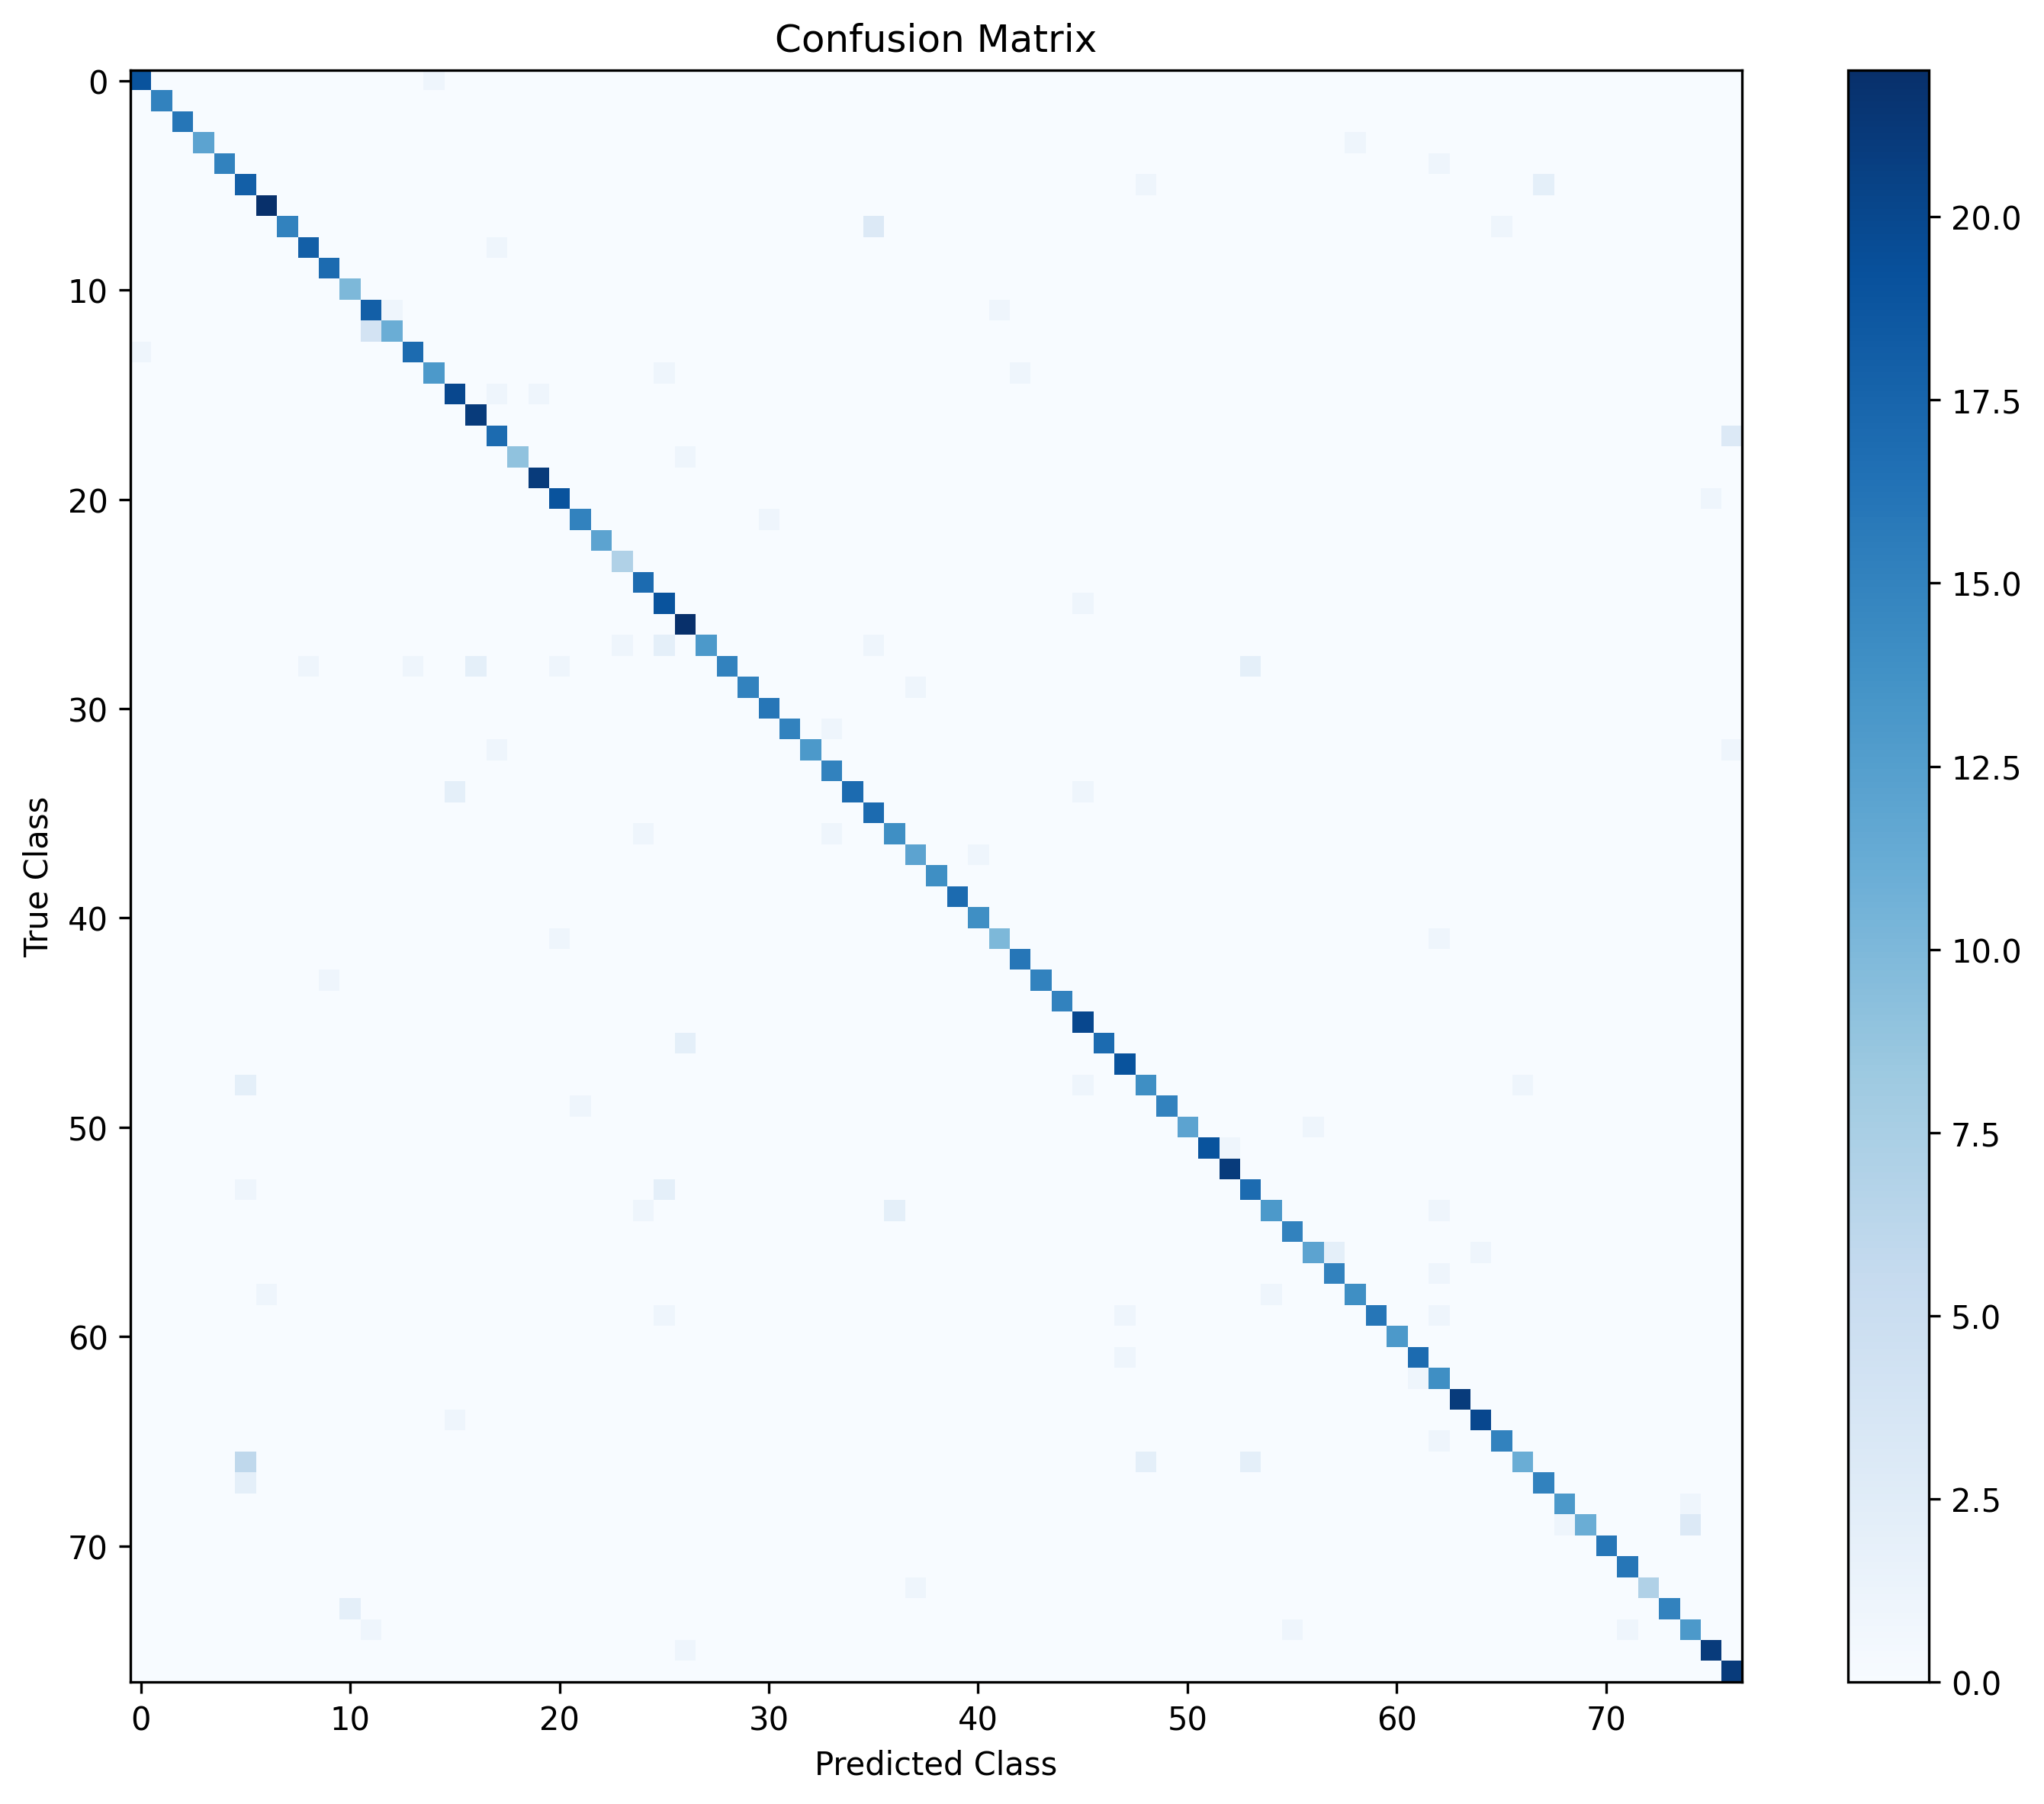


ROC Curve:


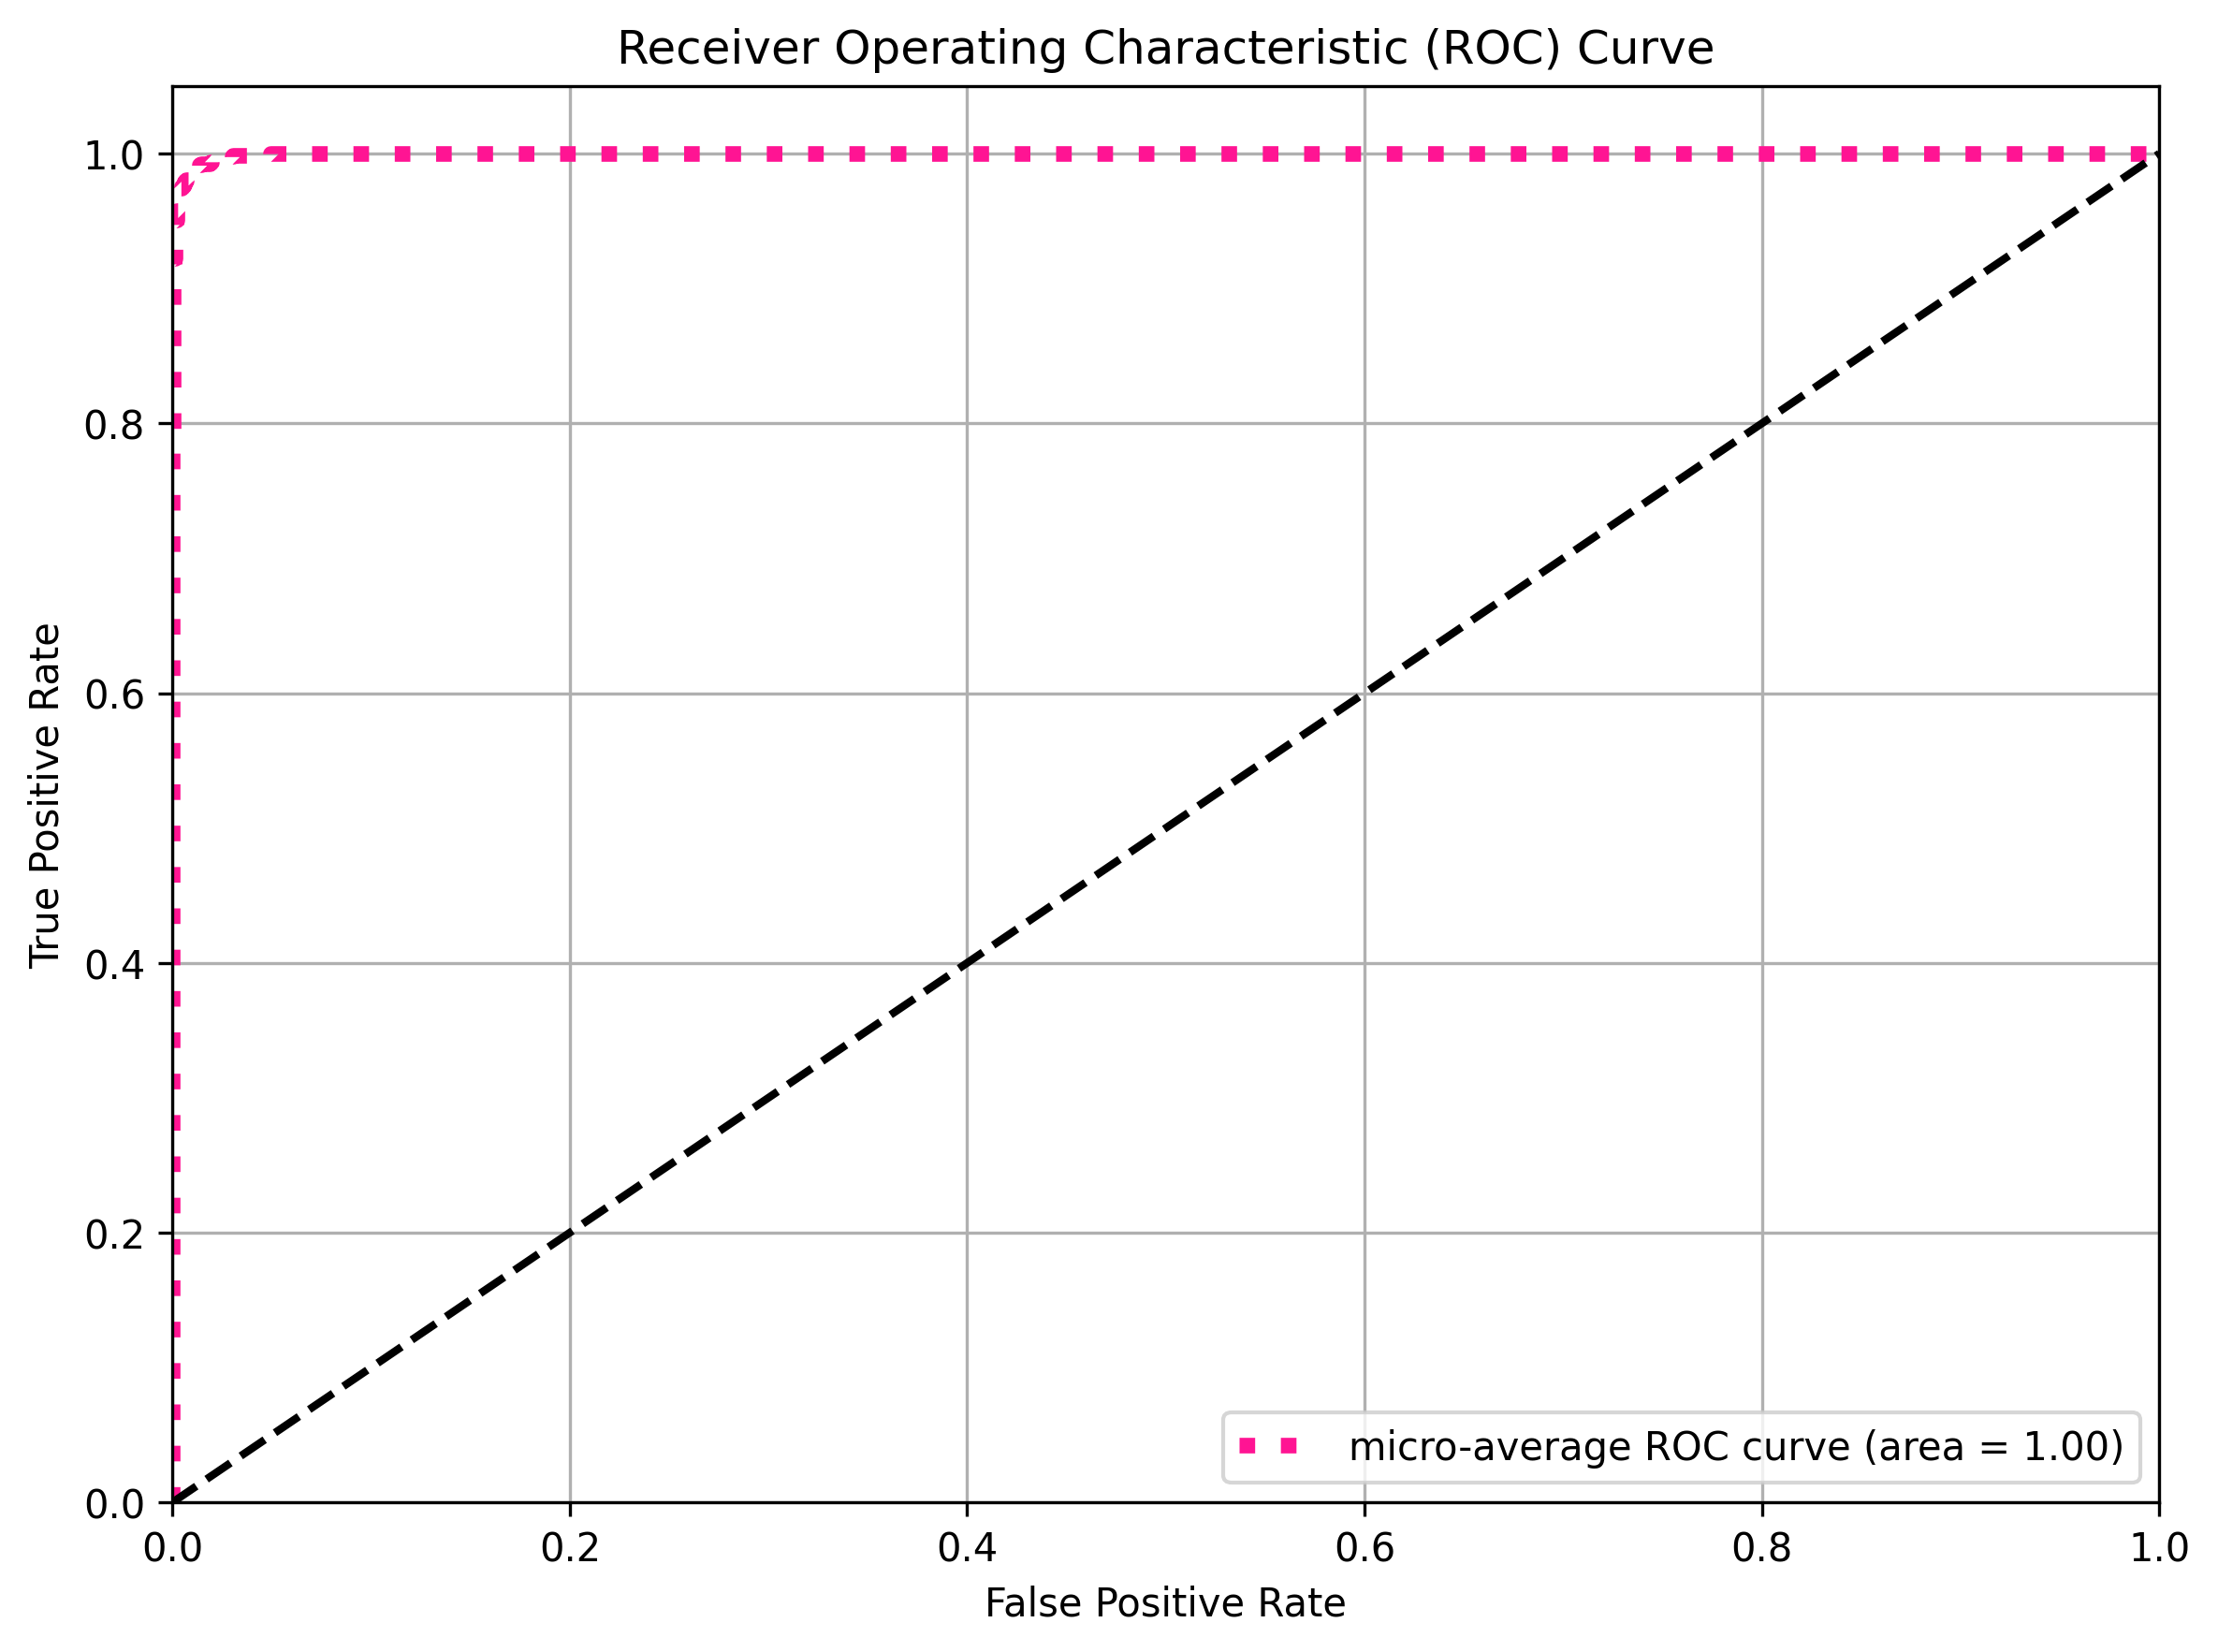


Precision-Recall Curve:


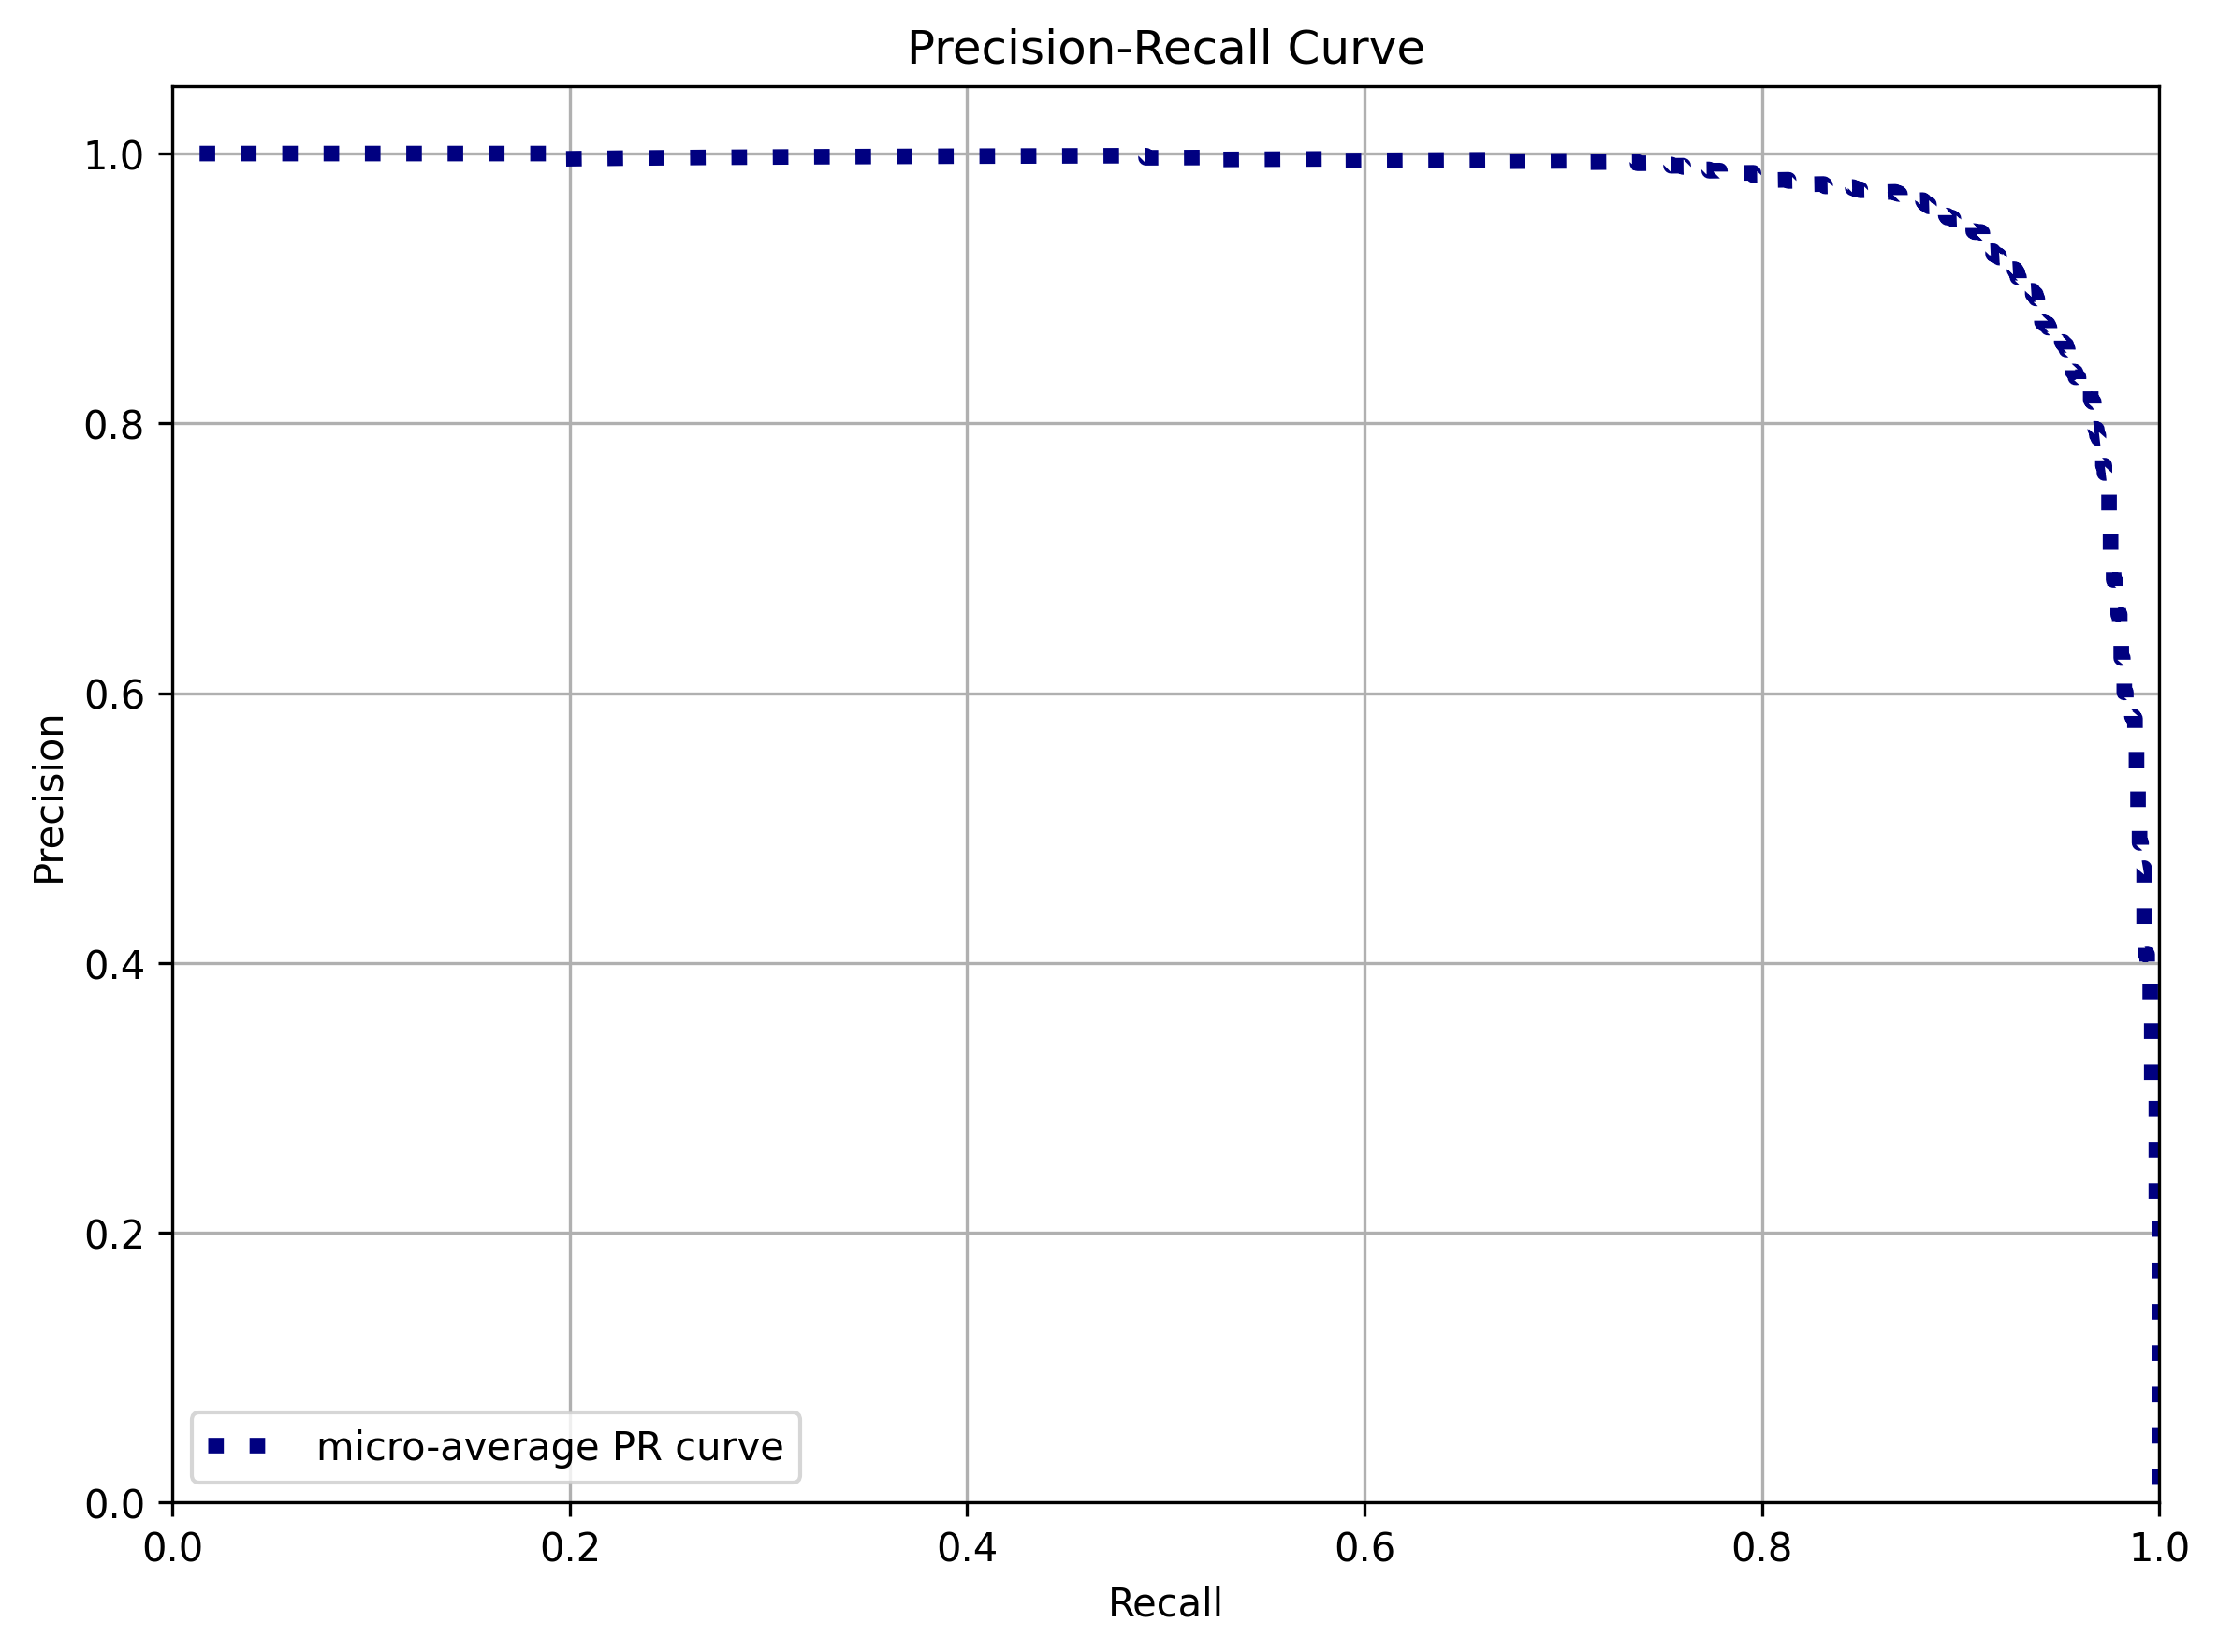

In [5]:
plots_dir = OUTPUT_DIR / "metrics" / "plots"

print("Confusion Matrix:")
display.display(display.Image(filename=str(plots_dir / "confusion_matrix.png")))

print("\nROC Curve:")
display.display(display.Image(filename=str(plots_dir / "roc_curve.png")))

print("\nPrecision-Recall Curve:")
display.display(display.Image(filename=str(plots_dir / "pr_curve.png")))

In [6]:
# Export Phase Manifest
import json

from src.api.app import get_git_commit
from src.utils.artifacts import save_yaml

eval_metrics_path = REPO_ROOT / "outputs" / "metrics" / "eval_metrics.json"
eval_metrics = {}
if eval_metrics_path.exists():
    with open(eval_metrics_path) as f:
        eval_metrics = json.load(f)

manifest = {
    "phase": "07_Model_Evaluation",
    "eval_metrics": eval_metrics,
    "git_commit": get_git_commit(),
}
save_yaml(manifest, REPO_ROOT / "outputs" / "manifests" / "phase_07_model_evaluation.yaml")
print("YAML manifest saved successfully:")
print(manifest)


[07/13/26 20:36:19] INFO     Saving YAML artifact to:                                                              
                             C:\Users\gunav\Downloads\SupportAI\outputs\manifests\phase_07_model_evaluation.yaml

YAML manifest saved successfully:
{'phase': '07_Model_Evaluation', 'eval_metrics': {'accuracy': 0.9185867895545314, 'macro_avg_f1': 0.9204597052489093, 'weighted_avg_f1': 0.9179924220192865}, 'git_commit': 'ef9a0498221c5c43373fcf9e951987614174868f'}
